<a href="https://colab.research.google.com/github/carlavilla/DataViz2025/blob/main/PS4_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploring factors that may impact Philadelphia's PIT count
**Background:** <br>
[1](https://www.phila.gov/2022-12-15-the-2023-pit-count-is-coming-what-it-is-why-its-important-and-how-you-can-help/#:~:text=The%20U.S.%20Department%20of%20Housing,in%20January%20every%20other%20year.) The Point-In-Time (PIT) Count is a national count of homeless people across the country. The US Department of Housing and Urban Development (HUD) requires that state and local governments receiving federal funding to address homelessness, known as Continuums of Care or CoC, to conduct an annual PIT Count in the month of January. <br>
[2](https://journals.sagepub.com/doi/epub/10.1177/2329496518812451), [3](https://www.thelancet.com/action/showPdf?pii=S2667-193X%2824%2900067-X) There have been criticisms about the accuracy of the PIT count. Most issues point to discrepancies across data collection methods and conditions outside of the protocol scope that may impact the number of individuals that get counted. Examples include number of counters, weather, hidden sheltering spaces (e.g. cars, abandoned structures), and criminalization of homelessness-adjacent activities.

**Definition of Homelessness as per [HUD](https://www.hudexchange.info/homelessness-assistance/coc-esg-virtual-binders/coc-esg-homeless-eligibility/four-categories/category-1/)** <br>
Individual or family who lacks a fixed, regular, and adequate nighttime residence, meaning:

1. Has a primary nighttime residence that is a public or private place not meant for human habitation; or
2. Is living in a publicly or privately operated shelter designated to provide temporary living arrangements (including congregate shelters, transitional housing, and hotels and motels paid for by charitable organizations or by federal, state and local government programs); or
3. Is exiting an institution where (s)he has resided for 90 days or less and who resided in an emergency shelter or place not meant for human habitation immediately before entering that institution.

**Sheltered individuals:** those in transitional housing, emergency shelters, other lodging funded or managed by a charitable organizations or government. <br>
**Unsheltered individuals:** those *visible* out in the public space. <br>
**Potentially missing individuals:** those *less visible* or 'marginally sheltered' (e.g. sleeping in vehicles, staying with family/friends temporarily). <br>
**How are these counted?** Those admitted to hospitals, incarcerated, warming centers

**Research questions:**
* What variables within the current data collection methods of the PIT count appear to impact the accuracy of the count?
* What variables outside of the data collection methods appear to impact the accuracy of the count?

#Environment set up

In [1]:
#setting up basic libraries
import time, os, sys, re
import zipfile, json, datetime, string
import numpy as np
from statistics import *
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as pdr
from pandas_datareader import wb
from pandas.io.formats.style import Styler

In [2]:
#setting up link to online data and Colab
import urllib
from google.colab import files
import seaborn as sns
from google.colab import data_table
data_table.enable_dataframe_formatter()

#Variables

##Variable 1: PIT Count
**Dataset Description:** Overall count of homeless individuals, subcounts for sheltered and unsheltered individuals from PIT counts in Philadelphia and Camden CoCs, years 2007 to 2024. Camden CoC covers the counties of Camden, Gloucester, Cape May, and Cumberland. <br>
**Relevance:** Dependent variable. Overall count and subcount of unsheltered homeless individuals is expected to change in line with independent variables. <br>
**Retrieved from:** Downloaded from [HUD PIT and HIC Data reservoir](https://www.hudexchange.info/resource/3031/pit-and-hic-data-since-2007/) on 4/8/2025.<br>
**Format:** .xlsb dataset that allows creation of a subtable. <br>
**Format for analyses:** Subtable was extracted for PA-500 CoC (Philadelphia) as an xlsx file. Data transposed on Excel.

####Dataset Prep (pit)

In [3]:
urllib.request.urlretrieve("https://docs.google.com/uc?id=1Ka2DAi3USpLnLmSge1ZYbvncAllkbM97&export=download", "HUDPIT_2007to2024.xlsx")

('HUDPIT_2007to2024.xlsx', <http.client.HTTPMessage at 0x79a4a9685d90>)

In [4]:
pit = pd.read_excel('HUDPIT_2007to2024.xlsx')

In [5]:
#checking headers and setting
pit.columns

Index(['Year', 'PhilPIT', 'CamPIT', 'PhilSHES', 'CamSHES', 'PhilSHTH',
       'CamSHTH', 'PhilSHSH', 'CamSHSH', 'PhilSH', 'CamSH', 'PhilUN', 'CamUN'],
      dtype='object')

In [7]:
pit.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Year,18.0,2015.50,5.34,2007.0,2011.25,2015.5,2019.75,2024.0
PhilPIT,18.0,3358.56,302.16,2871.0,3085.00,3343.5,3561.50,3869.0
CamPIT,18.0,774.67,110.84,603.0,707.25,752.5,828.75,1005.0
PhilSHES,18.0,2050.06,207.95,1696.0,1880.00,2088.0,2231.00,2329.0
CamSHES,18.0,459.00,86.27,345.0,388.25,459.0,500.50,654.0
PhilSHTH,18.0,499.44,374.22,170.0,282.75,411.5,517.00,1726.0
CamSHTH,18.0,137.11,37.36,87.0,110.75,131.0,164.25,208.0
PhilSHSH,15.0,151.20,75.52,66.0,80.50,113.0,214.50,268.0
CamSHSH,15.0,5.87,12.16,0.0,0.00,0.0,0.00,31.0
PhilSH,18.0,2675.50,272.21,2171.0,2515.50,2688.5,2771.25,3422.0


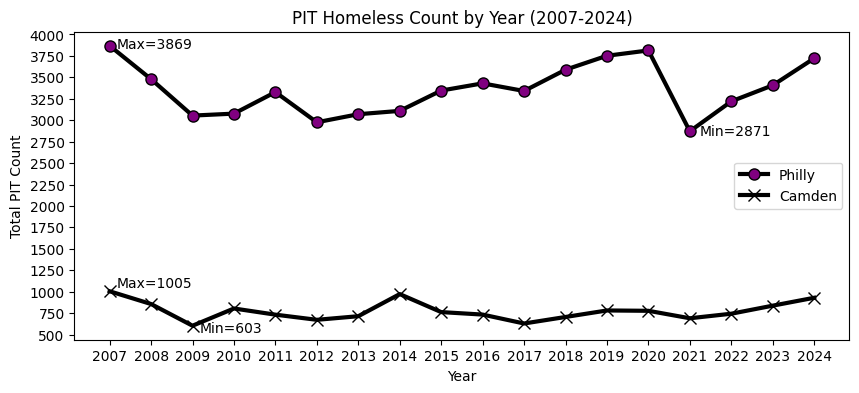

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'PhilPIT', data=pit, marker='o', markerfacecolor='purple', markersize=8, color='black', linewidth=3, label="Philly")
ax.plot( 'Year', 'CamPIT', data=pit, marker='x', markerfacecolor='green', markersize=8, color='black', linewidth=3, label="Camden")
ax.legend(loc='center right')
ax.set_yticks([500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

medpitp=pit.PhilPIT.median()
minpitp=pit.PhilPIT.min()
maxpitp=pit.PhilPIT.max()
# Find the year corresponding to the median value
#medpitp_year = pit.loc[pit['PhilPIT'] == medpitp, 'Year'].iloc[0]
minpitp_year = pit.loc[pit['PhilPIT'] == minpitp, 'Year'].iloc[0]
maxpitp_year = pit.loc[pit['PhilPIT'] == maxpitp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medpitp}', (medpitp_year, medpitp),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpitp}', (minpitp_year, minpitp),fontsize=10, xytext=(7, -3), textcoords='offset points')
ax.annotate(f'Max={maxpitp}', (maxpitp_year, maxpitp),fontsize=10, xytext=(5, -2), textcoords='offset points')

medpitc=pit.CamPIT.median()
minpitc=pit.CamPIT.min()
maxpitc=pit.CamPIT.max()
# Find the year corresponding to the median value
#medpitc_year = pit.loc[pit['CamPIT'] == medpitc, 'Year'].iloc[0]
minpitc_year = pit.loc[pit['CamPIT'] == minpitc, 'Year'].iloc[0]
maxpitc_year = pit.loc[pit['CamPIT'] == maxpitc, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medpitc}', (medpitc_year, medpitc),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpitc}', (minpitc_year, minpitc),fontsize=10, xytext=(5, -5), textcoords='offset points')
ax.annotate(f'Max={maxpitc}', (maxpitc_year, maxpitc),fontsize=10, xytext=(5, 3), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Total PIT Count')
plt.title('PIT Homeless Count by Year (2007-2024)');

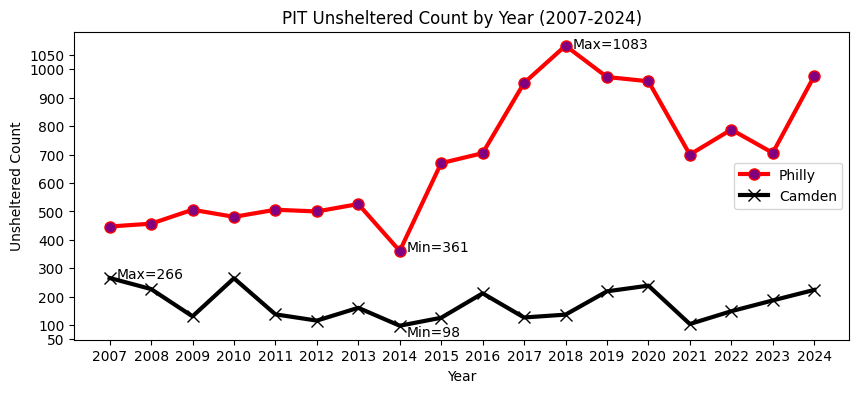

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'PhilUN', data=pit, marker='o', markerfacecolor='purple', markersize=8, color='red', linewidth=3, label="Philly")
ax.plot( 'Year', 'CamUN', data=pit, marker='x', markerfacecolor='green', markersize=8, color='black', linewidth=3, label="Camden")
ax.legend(loc='center right')
ax.set_yticks([50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1050])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

medunp=pit.PhilUN.median()
minunp=pit.PhilUN.min()
maxunp=pit.PhilUN.max()
# Find the year corresponding to the median value
#medunp_year = pit.loc[pit['PhilUN'] == medunp, 'Year'].iloc[0]
minunp_year = pit.loc[pit['PhilUN'] == minunp, 'Year'].iloc[0]
maxunp_year = pit.loc[pit['PhilUN'] == maxunp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medunp}', (medunp_year, medunp),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minunp}', (minunp_year, minunp),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxunp}', (maxunp_year, maxunp),fontsize=10, xytext=(5, -2), textcoords='offset points')

medunc=pit.CamUN.median()
minunc=pit.CamUN.min()
maxunc=pit.CamUN.max()
# Find the year corresponding to the median value
#medunc_year = pit.loc[pit['CamUN'] == medunc, 'Year'].iloc[0]
minunc_year = pit.loc[pit['CamUN'] == minunc, 'Year'].iloc[0]
maxunc_year = pit.loc[pit['CamUN'] == maxunc, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medunc}', (medunc_year, medunc),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minunc}', (minunc_year, minunc),fontsize=10, xytext=(5, -8), textcoords='offset points')
ax.annotate(f'Max={maxunc}', (maxunc_year, maxunc),fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Unsheltered Count')
plt.title('PIT Unsheltered Count by Year (2007-2024)');

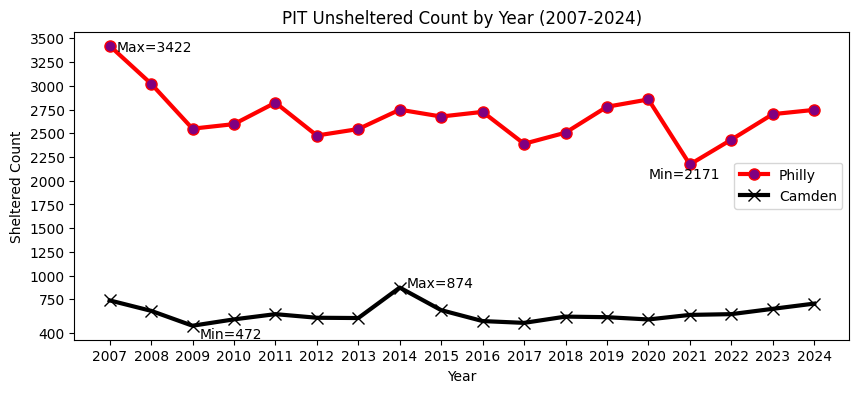

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'PhilSH', data=pit, marker='o', markerfacecolor='purple', markersize=8, color='red', linewidth=3, label="Philly")
ax.plot( 'Year', 'CamSH', data=pit, marker='x', markerfacecolor='green', markersize=8, color='black', linewidth=3, label="Camden")
ax.legend(loc='center right')
ax.set_yticks([400, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

medshp=pit.PhilSH.median()
minshp=pit.PhilSH.min()
maxshp=pit.PhilSH.max()
# Find the year corresponding to the median value
#medshp_year = pit.loc[pit['PhilSH'] == medshp, 'Year'].iloc[0]
minshp_year = pit.loc[pit['PhilSH'] == minshp, 'Year'].iloc[0]
maxshp_year = pit.loc[pit['PhilSH'] == maxshp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medshp}', (medshp_year, medshp),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minshp}', (minshp_year, minshp),fontsize=10, xytext=(-30, -10), textcoords='offset points')
ax.annotate(f'Max={maxshp}', (maxshp_year, maxshp),fontsize=10, xytext=(5, -4), textcoords='offset points')

medshc=pit.CamSH.median()
minshc=pit.CamSH.min()
maxshc=pit.CamSH.max()
# Find the year corresponding to the median value
#medshc_year = pit.loc[pit['CamSH'] == medshc, 'Year'].iloc[0]
minshc_year = pit.loc[pit['CamSH'] == minshc, 'Year'].iloc[0]
maxshc_year = pit.loc[pit['CamSH'] == maxshc, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medshc}', (medshc_year, medshc),fontsize=10, xytext=(10, -12), textcoords='offset points')
ax.annotate(f'Min={minshc}', (minshc_year, minshc),fontsize=10, xytext=(5, -9), textcoords='offset points')
ax.annotate(f'Max={maxshc}', (maxshc_year, maxshc),fontsize=10, xytext=(5, 0), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Sheltered Count')
plt.title('PIT Unsheltered Count by Year (2007-2024)');

##Variable 2: Temperature
**Dataset Description:** Mean for minimum temperature in Fahrenheit per month 2007-2023. <br>
**Relevance:** Independent variable. Lower temperatures may force unsheltered homeless people to seek out formal shelter and informal shelter (e.g. public transit, someone's couch) thus reducing overall count. <br>
**Retrieved from:** Downloaded from the [National Weather Service](https://www.weather.gov/wrh/Climate?wfo=phi) on 2/12/2025.<br>
**Format:** data table generated within webpage, available for printing or download as pdf only. <br>
**Format for analyses:** Attempted to read pdf for analyses but could not figure out this time. Ended up converting the pdf to an .xlsx file on Adobe Acrobat. Cleaning of headers on Excel.

####Dataset prep (tempJan)

In [11]:
#retrieving .xlsx document converted on Adobe Acrobat, cleaned on Excel
urllib.request.urlretrieve("https://drive.google.com/uc?id=1myHP4UxOXomqz5JSAYJyo5L3R5v-KW_b&export=download", "min_temp_2007to2023.xlsx")
tempx=pd.read_excel('min_temp_2007to2023.xlsx')

In [12]:
tempx.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'Annual'],
      dtype='object')

In [13]:
tempJan= tempx[['Year','Jan']]

In [14]:
tempJan= tempJan.rename(columns={'Jan': 'Temp'})
tempJan.columns

Index(['Year', 'Temp'], dtype='object')

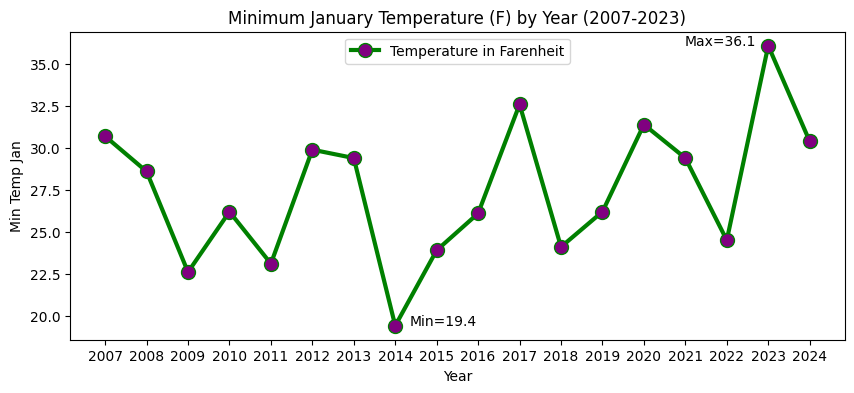

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot('Year', 'Temp', data=tempJan, marker='o', markerfacecolor='purple', markersize=10, color='green', linewidth=3, label= 'Temperature in Farenheit')
ax.legend(loc='upper center')
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

#medtemp=tempJan.Temp.median()
mintemp=tempJan.Temp.min()
maxtemp=tempJan.Temp.max()
# Find the year corresponding to the median value
#mediantemp_year = tempJan.loc[tempJan['Temp'] == medtemp, 'Year'].iloc[0]
mintemp_year = tempJan.loc[tempJan['Temp'] == mintemp, 'Year'].iloc[0]
maxtemp_year = tempJan.loc[tempJan['Temp'] == maxtemp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medtemp}', (mediantemp_year, medtemp),fontsize=10, xytext=(-20, 8), textcoords='offset points')
ax.annotate(f'Min={mintemp}', (mintemp_year, mintemp),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxtemp}', (maxtemp_year, maxtemp),fontsize=10, xytext=(-60, 0), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Min Temp Jan')
plt.title('Minimum January Temperature (F) by Year (2007-2023)');

##Variable 3: Precipitation
**Dataset Description:** Mean precipitation in inches for each month 2007-2024. <br>
**Relevance:** Independent variable. Higher precipitation may force homeless people to seek out last-resort informal shelter, reducing overall count. <br>
**Retrieved from:** Downloaded from the [National Weather Service](https://www.weather.gov/wrh/Climate?wfo=phi) on 2/12/2025.<br>
**Format:** data table generated within webpage, available for printing or download as pdf only. <br>
**Format for analyses:** Converted the pdf to an .xlsx file on Adobe Acrobat. Attempting cleaning here.

####Dataset prep (precip5)

In [16]:
#true headers at Index 1, first column not valid
urllib.request.urlretrieve("https://drive.google.com/uc?id=1vm5e50vTZJoyGvA75OtmboqdpHtNWtHA&export=download", "mean_precip_2007to2023.xlsx")
precip = pd.read_excel('mean_precip_2007to2023.xlsx')
precip.head(3)
#you can tell python where the header stars- find command to designate header

,"2/13/25, 12:49 AM about:blank",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Monthly Mean Precipitation for Philadelphia A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
2,NaN,2007,0.11,0.06,0.12,0.3,0.09,0.13,0.11,0.09,0.02,0.15,0.05,0.14,0.11


In [17]:
#only need data for each year, do not need Index 20 to 24
precip.tail(7)

,"2/13/25, 12:49 AM about:blank",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
18,NaN,2023,0.11,0.05,0.06,0.17,0.01,0.14,0.17,0.1,0.2,0.02,0.09,0.26,0.12
19,NaN,2024,0.19,0.05,0.23,0.14,0.06,0.16,0.08,0.16,0.03,T,0.08,0.11,0.11
20,NaN,Mean,0.1,0.11,0.12,0.13,0.11,0.15,0.15,0.17,0.14,0.11,0.09,0.15,0.13
21,NaN,Max,0.19,0.22,0.24,0.3,0.21,0.35,0.43,0.62,0.34,0.19,0.3,0.29,0.18
22,NaN,NaN,2024,2018,2010,2007,2016,2013,2013,2011,2011,2022,2018,2009,NaN
23,NaN,Min,0.05,0.03,0.03,0.06,0.01,0.06,0.05,0.03,0.02,T,0.02,0.04,0.1
24,NaN,NaN,2021,2009,2012,2016,2023,2017,2012,2015,2007,2024,2021,2017,NaN


In [18]:
precip2= precip.rename(columns={'Unnamed: 1': 'Year', 'Unnamed: 2': 'Precip'})
precip2.head()

,"2/13/25, 12:49 AM about:blank",Year,Precip,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,NaN,Monthly Mean Precipitation for Philadelphia A...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
2,NaN,2007,0.11,0.06,0.12,0.3,0.09,0.13,0.11,0.09,0.02,0.15,0.05,0.14,0.11
3,NaN,2008,0.06,0.14,0.12,0.07,0.15,0.1,0.11,0.08,0.14,0.05,0.13,0.18,0.11
4,NaN,2009,0.09,0.03,0.05,0.13,0.16,0.16,0.11,0.33,0.12,0.18,0.07,0.29,0.14


In [19]:
#removing irrelevant data
precip3= precip2[['Year', 'Precip']]
precip3.head()


,Year,Precip
0,Monthly Mean Precipitation for Philadelphia A...,NaN
1,Year,Jan
2,2007,0.11
3,2008,0.06
4,2009,0.09


In [20]:
#removing extraneous rows
precip4 = precip3.drop(precip3.index[0:2])
precip4.head()

,Year,Precip
2,2007,0.11
3,2008,0.06
4,2009,0.09
5,2010,0.07
6,2011,0.11


In [21]:
#checking index for tail
precip4.tail(7)

,Year,Precip
18,2023,0.11
19,2024,0.19
20,Mean,0.1
21,Max,0.19
22,NaN,2024
23,Min,0.05
24,NaN,2021


In [22]:
#reseting index so I can delete the correct indeces
precip_reset= precip4.reset_index(drop=True)
precip_reset.tail(7)

,Year,Precip
16,2023,0.11
17,2024,0.19
18,Mean,0.1
19,Max,0.19
20,NaN,2024
21,Min,0.05
22,NaN,2021


In [23]:
#dropping extraneous tail indices
precip5= precip_reset.drop(precip_reset.index[18:])
precip5.tail()

,Year,Precip
13,2020,0.09
14,2021,0.05
15,2022,0.11
16,2023,0.11
17,2024,0.19


In [24]:
precip5.head()

,Year,Precip
0,2007,0.11
1,2008,0.06
2,2009,0.09
3,2010,0.07
4,2011,0.11


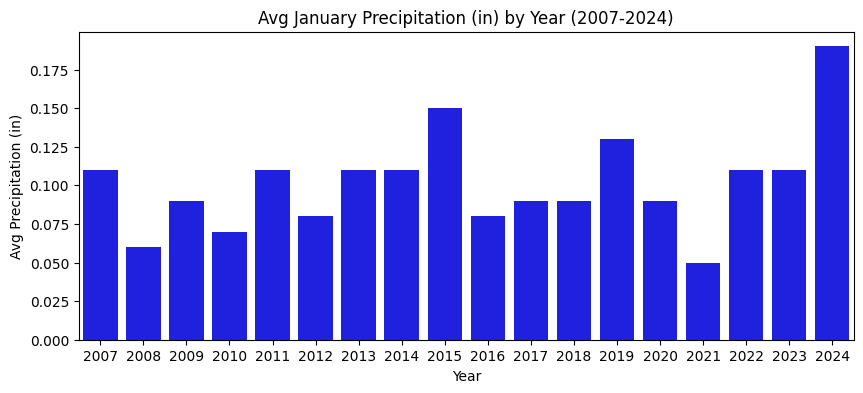

In [25]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="Precip", data=precip5, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='blue')
plt.xlabel('Year')
plt.ylabel('Avg Precipitation (in)')
plt.title('Avg January Precipitation (in) by Year (2007-2024)');

##Variable 4: Demolitions
**Dataset Description:** Number of property demolitions initiated in Philadelphia 2007 to 2025. <br>
**Relevance:** Demolition of empty structures may result in fewer informal shelter opportunities for homeless folk, resulting in more visible homeless people during the count in January. <br>
**Retrieved from:** Downloaded from [Open Data Philly](https://opendataphilly.org/datasets/building-demolitions/) on 2/12/2025. <br>
**Format:** csv available on website for download <br>
**Format for analyses:** Demolitions are listed by address so there are multiple entries per year. Created a new sheet and used the Excel CountIf function to count demolitions for each calendar year. Since the demolitions for a given year (e.g. 2007) would hypothetically impact the count in January of the following year (e.g. 2008), a second column was created on Excel as "pit year" to indicate the year the data coulw be relevant for. Since .csv docs do now allow multiple sheets, the spreadsheet was saved as a .xlsx


####Dataset prep (demo3)

In [26]:
import pandas as pd
urllib.request.urlretrieve("https://drive.google.com/uc?id=1i_Uc-gNSdaHFVDcaCbX4o2CN04EvNEx7&export=download", "demolitions_2007to2025.xlsx")
demo=pd.read_excel('demolitions_2007to2025.xlsx', sheet_name='Sheet1')

In [27]:
demo.columns

Index(['year', 'year pit', 'Demolition count'], dtype='object')

In [28]:
demo2 = demo.drop(columns=['year'])
demo2.columns

Index(['year pit', 'Demolition count'], dtype='object')

In [29]:
#renaming year column to prep for merging
#QUESTION: Why do I have to create a new dataframe here whereas I didn't to do that for renaming it in the pit dataframe?
demo3=demo2.rename(columns={'year pit': 'Year'})
demo3.columns

Index(['Year', 'Demolition count'], dtype='object')

In [30]:
demo3=demo3.rename(columns={'Demolition count': 'demos'})
demo3.columns

Index(['Year', 'demos'], dtype='object')

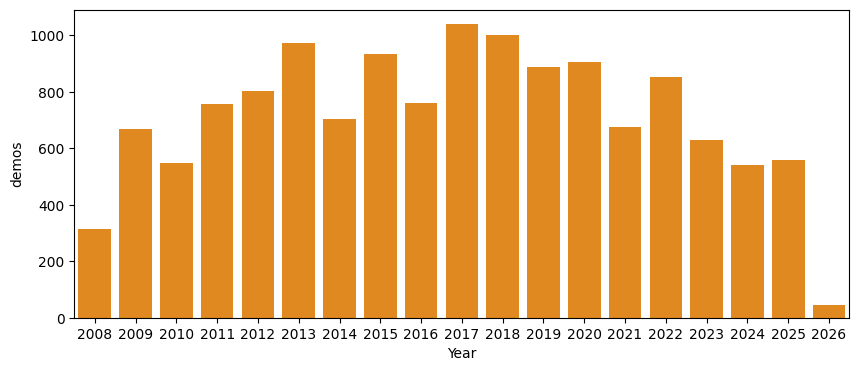

In [31]:
fig, ax = plt.subplots(figsize=(10,4))
ax = sns.barplot(x="Year", y="demos", data=demo3, estimator=np.mean, errorbar=('ci', 95), capsize=.1, color='darkorange')

meddem=demo3.demos.median()
mindem=demo3.demos.min()
maxdem=demo3.demos.max()
meddem_year = demo3.loc[demo3['demos'] == meddem, 'Year'].iloc[0]
mindem_year = demo3.loc[demo3['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = demo3.loc[demo3['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(5, 0), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(5, 0), textcoords='offset points');
#ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
               # ha='center', va='center', xytext=(0, 8), textcoords='offset points')


#Merging Datasets


In [32]:
merged_df = pd.merge(pit, tempJan, on='Year', how='outer', indicator='merged')
merged_df

,Year,PhilPIT,CamPIT,PhilSHES,CamSHES,PhilSHTH,CamSHTH,PhilSHSH,CamSHSH,PhilSH,CamSH,PhilUN,CamUN,Temp,merged
0,2007,3869,1005,1696,577,1726,162,NaN,NaN,3422,739,447,266,30.7,both
1,2008,3479,856,1895,508,1127,121,NaN,NaN,3022,629,457,227,28.6,both
2,2009,3054,603,2155,362,393,110,NaN,NaN,2548,472,506,131,22.6,both
3,2010,3077,804,2161,452,363,87,72.0,0.0,2596,539,481,265,26.2,both
4,2011,3328,732,2251,466,505,128,66.0,0.0,2822,594,506,138,23.1,both
5,2012,2976,672,1857,469,553,87,66.0,0.0,2476,556,500,116,29.9,both
6,2013,3070,714,1844,374,601,179,99.0,0.0,2544,553,526,161,29.4,both
7,2014,3109,972,2130,654,505,189,113.0,31.0,2748,874,361,98,19.4,both
8,2015,3346,762,2046,428,521,208,109.0,0.0,2676,636,670,126,23.9,both
9,2016,3430,733,2174,356,474,165,77.0,0.0,2725,521,705,212,26.1,both


In [33]:
merged_df['merged'].value_counts()

,count
merged,
both,18
left_only,0
right_only,0


Merge was succesful. No unmerged items, as expected given that both datasets ranged from years 2007 to 2024.

In [34]:
merged_df = pd.merge(merged_df, precip5, on='Year', how='outer', indicator='merged2')
merged_df

,Year,PhilPIT,CamPIT,PhilSHES,CamSHES,PhilSHTH,CamSHTH,PhilSHSH,CamSHSH,PhilSH,CamSH,PhilUN,CamUN,Temp,merged,Precip,merged2
0,2007,3869,1005,1696,577,1726,162,NaN,NaN,3422,739,447,266,30.7,both,0.11,both
1,2008,3479,856,1895,508,1127,121,NaN,NaN,3022,629,457,227,28.6,both,0.06,both
2,2009,3054,603,2155,362,393,110,NaN,NaN,2548,472,506,131,22.6,both,0.09,both
3,2010,3077,804,2161,452,363,87,72.0,0.0,2596,539,481,265,26.2,both,0.07,both
4,2011,3328,732,2251,466,505,128,66.0,0.0,2822,594,506,138,23.1,both,0.11,both
5,2012,2976,672,1857,469,553,87,66.0,0.0,2476,556,500,116,29.9,both,0.08,both
6,2013,3070,714,1844,374,601,179,99.0,0.0,2544,553,526,161,29.4,both,0.11,both
7,2014,3109,972,2130,654,505,189,113.0,31.0,2748,874,361,98,19.4,both,0.11,both
8,2015,3346,762,2046,428,521,208,109.0,0.0,2676,636,670,126,23.9,both,0.15,both
9,2016,3430,733,2174,356,474,165,77.0,0.0,2725,521,705,212,26.1,both,0.08,both


In [35]:
merged_df['merged2'].value_counts()

,count
merged2,
both,18
left_only,0
right_only,0


Merge was successful. No unmerged items, as expected given that the three datasets ranged from years 2007 to 2024.

In [36]:
pitmerged1= pd.merge(merged_df, demo3, on='Year', how='outer', indicator='merged3')
pitmerged1

,Year,PhilPIT,CamPIT,PhilSHES,CamSHES,PhilSHTH,CamSHTH,PhilSHSH,CamSHSH,PhilSH,CamSH,PhilUN,CamUN,Temp,merged,Precip,merged2,demos,merged3
0,2007,3869.0,1005.0,1696.0,577.0,1726.0,162.0,NaN,NaN,3422.0,739.0,447.0,266.0,30.7,both,0.11,both,NaN,left_only
1,2008,3479.0,856.0,1895.0,508.0,1127.0,121.0,NaN,NaN,3022.0,629.0,457.0,227.0,28.6,both,0.06,both,315.0,both
2,2009,3054.0,603.0,2155.0,362.0,393.0,110.0,NaN,NaN,2548.0,472.0,506.0,131.0,22.6,both,0.09,both,667.0,both
3,2010,3077.0,804.0,2161.0,452.0,363.0,87.0,72.0,0.0,2596.0,539.0,481.0,265.0,26.2,both,0.07,both,548.0,both
4,2011,3328.0,732.0,2251.0,466.0,505.0,128.0,66.0,0.0,2822.0,594.0,506.0,138.0,23.1,both,0.11,both,758.0,both
5,2012,2976.0,672.0,1857.0,469.0,553.0,87.0,66.0,0.0,2476.0,556.0,500.0,116.0,29.9,both,0.08,both,803.0,both
6,2013,3070.0,714.0,1844.0,374.0,601.0,179.0,99.0,0.0,2544.0,553.0,526.0,161.0,29.4,both,0.11,both,974.0,both
7,2014,3109.0,972.0,2130.0,654.0,505.0,189.0,113.0,31.0,2748.0,874.0,361.0,98.0,19.4,both,0.11,both,703.0,both
8,2015,3346.0,762.0,2046.0,428.0,521.0,208.0,109.0,0.0,2676.0,636.0,670.0,126.0,23.9,both,0.15,both,935.0,both
9,2016,3430.0,733.0,2174.0,356.0,474.0,165.0,77.0,0.0,2725.0,521.0,705.0,212.0,26.1,both,0.08,both,762.0,both


In [37]:
pitmerged1['merged3'].value_counts()

,count
merged3,
both,17
right_only,2
left_only,1


Merge successful. Left_only merge was for year 2007 since Demolition data only starts at year 2008. Right_only merges correspond to data for years 2025 and 2026, since other data sets only go up to year 2024. These unmatched datapoints will be removed.

In [38]:
pitmerged= pd.merge(merged_df, demo3, on='Year', how='inner', indicator='merged3')
pitmerged

,Year,PhilPIT,CamPIT,PhilSHES,CamSHES,PhilSHTH,CamSHTH,PhilSHSH,CamSHSH,PhilSH,CamSH,PhilUN,CamUN,Temp,merged,Precip,merged2,demos,merged3
0,2008,3479,856,1895,508,1127,121,NaN,NaN,3022,629,457,227,28.6,both,0.06,both,315,both
1,2009,3054,603,2155,362,393,110,NaN,NaN,2548,472,506,131,22.6,both,0.09,both,667,both
2,2010,3077,804,2161,452,363,87,72.0,0.0,2596,539,481,265,26.2,both,0.07,both,548,both
3,2011,3328,732,2251,466,505,128,66.0,0.0,2822,594,506,138,23.1,both,0.11,both,758,both
4,2012,2976,672,1857,469,553,87,66.0,0.0,2476,556,500,116,29.9,both,0.08,both,803,both
5,2013,3070,714,1844,374,601,179,99.0,0.0,2544,553,526,161,29.4,both,0.11,both,974,both
6,2014,3109,972,2130,654,505,189,113.0,31.0,2748,874,361,98,19.4,both,0.11,both,703,both
7,2015,3346,762,2046,428,521,208,109.0,0.0,2676,636,670,126,23.9,both,0.15,both,935,both
8,2016,3430,733,2174,356,474,165,77.0,0.0,2725,521,705,212,26.1,both,0.08,both,762,both
9,2017,3341,629,1875,345,430,157,84.0,0.0,2389,502,952,127,32.6,both,0.09,both,1039,both


In [39]:
pitmerged.columns

Index(['Year', 'PhilPIT', 'CamPIT', 'PhilSHES', 'CamSHES', 'PhilSHTH',
       'CamSHTH', 'PhilSHSH', 'CamSHSH', 'PhilSH', 'CamSH', 'PhilUN', 'CamUN',
       'Temp', 'merged', 'Precip', 'merged2', 'demos', 'merged3'],
      dtype='object')

In [40]:
pitmerged= pitmerged.drop(columns=['merged', 'merged2', 'merged3'])
pitmerged.columns

Index(['Year', 'PhilPIT', 'CamPIT', 'PhilSHES', 'CamSHES', 'PhilSHTH',
       'CamSHTH', 'PhilSHSH', 'CamSHSH', 'PhilSH', 'CamSH', 'PhilUN', 'CamUN',
       'Temp', 'Precip', 'demos'],
      dtype='object')

#Visuals (pitmerged)

##Correlations between variables
**Goal:** Check for correlations between the dependent and independent variables, as well as potential multicollinearity between independent variables. Multicollinearity would indicate that two independent variables are related, and this could impact how each of these variables' relationship to the PIT counts are interpreted.

In [43]:
pitmerged[['PhilPIT','CamPIT', 'PhilSH', 'CamSH', 'PhilUN', 'CamUN', 'Temp', 'Precip', 'demos', 'Year']].corr().round(2)

,PhilPIT,CamPIT,PhilSH,CamSH,PhilUN,CamUN,Temp,Precip,demos,Year
PhilPIT,1.00,0.33,0.62,0.03,0.70,0.57,0.20,0.45,0.09,0.41
CamPIT,0.33,1.00,0.59,0.85,-0.12,0.37,-0.06,0.41,-0.50,0.20
PhilSH,0.62,0.59,1.00,0.30,-0.13,0.57,-0.09,0.27,-0.39,-0.24
CamSH,0.03,0.85,0.30,1.00,-0.24,-0.18,-0.25,0.40,-0.31,0.18
PhilUN,0.70,-0.12,-0.13,-0.24,1.00,0.20,0.34,0.32,0.47,0.73
CamUN,0.57,0.37,0.57,-0.18,0.20,1.00,0.32,0.07,-0.39,0.06
Temp,0.20,-0.06,-0.09,-0.25,0.34,0.32,1.00,-0.06,-0.04,0.42
Precip,0.45,0.41,0.27,0.40,0.32,0.07,-0.06,1.00,0.15,0.41
demos,0.09,-0.50,-0.39,-0.31,0.47,-0.39,-0.04,0.15,1.00,0.25
Year,0.41,0.20,-0.24,0.18,0.73,0.06,0.42,0.41,0.25,1.00


<Axes: >

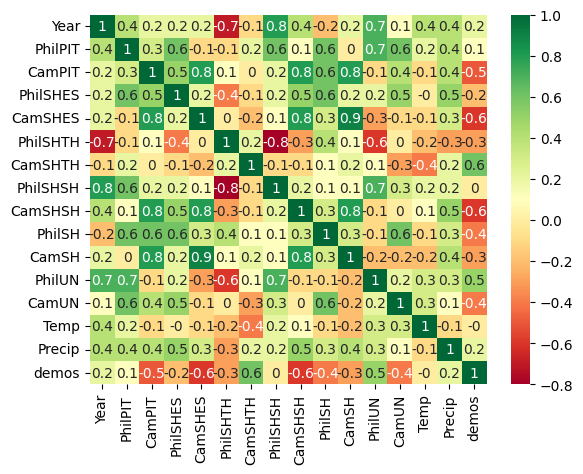

In [44]:
sns.heatmap(pitmerged.corr().round(1),cmap="RdYlGn",annot=True)

**Correlation Matrix:** The correlation matrix points to some potential correlations of interest, namely:<br>

* TIME: Increasing number of unsheltered people (r=.73) and overall Sheltered in Safe Haven people (r=.8) in Philadelphia over time. Decreasing number of people Sheltered in Transitional housing (r= -.7) in Philadelphia over time. Moderately, increasing temperature (r=.42) and precipitation (r=.41) over time.
* TEMP: Moderately, decreasing number of people sheltered in Transitional Housing (r= -.4) in Camden as temperature increases.
* PRECIPITATION: Moderately, increasing number of people sheltered in Emergency Shelter in Philly (r= .5) and people sheltered in Safe Havens in Camden (r= .5) with increasing precipitation.
* PHILLY DEMOLITIONS: Decreasing number of people in Emergency Shelter and Safe Havens (r= -.6) and increasing number in Transitional Housing (r= .6) in Camden with increasing demolitions. Moderately, increasing Unsheltered count in Philly (r= .47) and decreasing number in Camden (r= -.39) with increasing demolitions.
* PHILLY UNSHELTERED: Increasing numbers with increase in people in SH (r= .7) and demolitions (r= .47) in Philly, decrease with people in TH (r= -.6) in Philly.
* CAMDEN UNSHELTERED: increasing numbers with increasing Philly Sheltered (r= .6) and Philly ES (r= .5), decreasing with increasing Philly demolitions (r= -.4).
* TRANSITIONAL HOUSING: increasing numbers in SH (-.8) and ES (-.4) in Philly with decreasing TH.

The recorded number of homeless individuals appears to be increasing over time in Philadelphia and not as evidently in Camden. It is possible that the number of homeless people is increasing as evidenced by the positive correlations between Unsheltered and Sheltered populations with the PIT counts for Philadelphia and Camden. **Next steps:** See if these patterns align with factors that are linked to homelessness (e.g. unemployment, rent/mortgage increase, historical events) <br>
It is also possible that Philadelphia has refined their data collection methods over time, leading to a more accurate count. **Next steps:** Mapping some of the methodological changes made to the data collection with the numbers might bring clarity to this. Could categorize events based on potential to increase/decrease unsheltered count. <br>
Additionally, given the proximity of Camden to Philadelphia and the different times of the PITs, it is possible that the homeless population may be moving between CoCs, resulting in some people getting double counted or not counted at all. It is interesting that the number of Camden Unsheltered people increases with higher numbers recorded in Philly shelters, which may indicate that Camden homeless people may rely on Philadelphia homeless shelters in addition to Camden's. The negative correlation with the unsheltered homeless in Camden and demolitions is Philly is curious. **Next steps:** it might be helpful to compare changes in Philly and Camden's unsheltered population further.







##Homelessness in Philadelphia
**Goal:** Review frequencies of variables to see general pattern of change overtime for each variable.

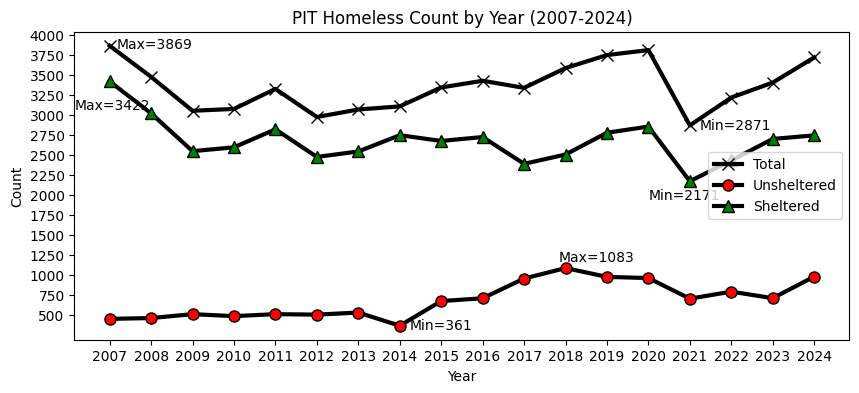

In [50]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot( 'Year', 'PhilPIT', data=pit, marker='x', markerfacecolor='black', markersize=8, color='black', linewidth=3, label="Total")
ax.plot( 'Year', 'PhilUN', data=pit, marker='o', markerfacecolor='red', markersize=8, color='black', linewidth=3, label="Unsheltered")
ax.plot( 'Year', 'PhilSH', data=pit, marker='^', markerfacecolor='green', markersize=8, color='black', linewidth=3, label="Sheltered")
ax.legend(loc='center right')
ax.set_yticks([500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

medpitp=pit.PhilPIT.median()
minpitp=pit.PhilPIT.min()
maxpitp=pit.PhilPIT.max()
# Find the year corresponding to the median value
#medpitp_year = pit.loc[pit['PhilPIT'] == medpitp, 'Year'].iloc[0]
minpitp_year = pit.loc[pit['PhilPIT'] == minpitp, 'Year'].iloc[0]
maxpitp_year = pit.loc[pit['PhilPIT'] == maxpitp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medpitp}', (medpitp_year, medpitp),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpitp}', (minpitp_year, minpitp),fontsize=10, xytext=(7, -3), textcoords='offset points')
ax.annotate(f'Max={maxpitp}', (maxpitp_year, maxpitp),fontsize=10, xytext=(5, -2), textcoords='offset points')

medshp=pit.PhilSH.median()
minshp=pit.PhilSH.min()
maxshp=pit.PhilSH.max()
# Find the year corresponding to the median value
#medshp_year = pit.loc[pit['PhilSH'] == medshp, 'Year'].iloc[0]
minshp_year = pit.loc[pit['PhilSH'] == minshp, 'Year'].iloc[0]
maxshp_year = pit.loc[pit['PhilSH'] == maxshp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medshp}', (medshp_year, medshp),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minshp}', (minshp_year, minshp),fontsize=10, xytext=(-30, -13), textcoords='offset points')
ax.annotate(f'Max={maxshp}', (maxshp_year, maxshp),fontsize=10, xytext=(-25, -20), textcoords='offset points')

medunp=pit.PhilUN.median()
minunp=pit.PhilUN.min()
maxunp=pit.PhilUN.max()
# Find the year corresponding to the median value
#medunp_year = pit.loc[pit['PhilUN'] == medunp, 'Year'].iloc[0]
minunp_year = pit.loc[pit['PhilUN'] == minunp, 'Year'].iloc[0]
maxunp_year = pit.loc[pit['PhilUN'] == maxunp, 'Year'].iloc[0]
# Annotate using the median year and median value
#ax.annotate(f'Median={medunp}', (medunp_year, medunp),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minunp}', (minunp_year, minunp),fontsize=10, xytext=(7, -3), textcoords='offset points')
ax.annotate(f'Max={maxunp}', (maxunp_year, maxunp),fontsize=10, xytext=(-5, 5), textcoords='offset points')

plt.xlabel('Year')
plt.ylabel('Count')
plt.title('PIT Homeless Count by Year (2007-2024)');

This graph shows how the trends in PIT numbers is highly dictated by the sheltered homeless. The trend for the less visible, unsheltered homeless appears to fluctuate less from year to year but also to be on a gradual increase over time.

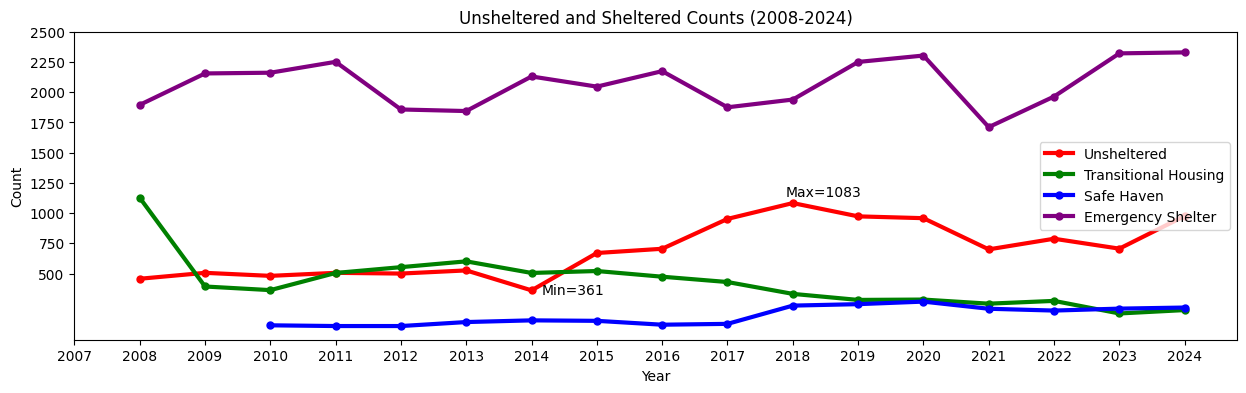

In [86]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'PhilUN', data=pitmerged, marker='o', markerfacecolor='red', markersize=5, color='red', linewidth=3, label="Unsheltered")
ax.plot( 'Year', 'PhilSHTH', data=pitmerged, marker='o', markerfacecolor='green', markersize=5, color='green', linewidth=3, label="Transitional Housing")
ax.plot( 'Year', 'PhilSHSH', data=pitmerged, marker='o', markerfacecolor='blue', markersize=5, color='blue', linewidth=3, label="Safe Haven")
ax.plot( 'Year', 'PhilSHES', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='purple', linewidth=3, label="Emergency Shelter")
ax.set_yticks([500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500])
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

# plot descriptives UN and SH Counts
medunp=pit.PhilUN.median()
minunp=pit.PhilUN.min()
maxunp=pit.PhilUN.max()
minunp_year = pit.loc[pit['PhilUN'] == minunp, 'Year'].iloc[0]
maxunp_year = pit.loc[pit['PhilUN'] == maxunp, 'Year'].iloc[0]
ax.annotate(f'Min={minunp}', (minunp_year, minunp),fontsize=10, xytext=(7, -3), textcoords='offset points')
ax.annotate(f'Max={maxunp}', (maxunp_year, maxunp),fontsize=10, xytext=(-5, 5), textcoords='offset points')

#plot visual notes
#ax.axvline(2014, color="green", ls="--")
#ax.axvline(2018, color="blue", ls="solid")
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Unsheltered and Sheltered Counts (2008-2024)')
ax.legend();

##PIT Methodology over time

In [80]:
dft = pd.DataFrame({'Year': [2007, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
                    'Change': ['HUD mandates PIT Count', 'Training and Canvas expansion', 'ER counted as shelter', 'Canvas expansion', 'Winter beds counted', 'nan', 'Tunnels counted', 'nan', 'Remote counting, SEPTA counted', 'nan', 'nan', 'nan'],
                    'UNimp': ['Increase', 'Increase', 'Decrease', 'Increase', 'Decrease', 'nan', 'Increase', 'nan', 'Decrease', 'nan', 'nan', 'nan'],
                    'Other': ['nan', 'Police sweeps, SSI checks', 'Fewer winter beds', 'Fewer winter beds', 'GOP convention, SEPTA free access, more winter beds', '100 day challenge, Terminals closed at 12AM', 'Police presence', 'SEPTA closed at 12AM', 'Stimulus checks, COVID hotels', 'nan', 'Warming centers open', 'nan'],
                    'UNimp2': ['nan', 'Decrease', 'Increase', 'Increase', 'Decrease', 'Decrease', 'Decrease', 'Increase', 'Decrease', 'nan', 'Decrease', 'nan']})

In [81]:
dftt = pd.merge(dft, pitmerged,how='outer',indicator=True)
merged_df['merged'].value_counts()

,count
merged,
both,18
left_only,0
right_only,0


In [82]:
display(dftt)

,Year,Change,UNimp,Other,UNimp2,PhilPIT,CamPIT,PhilSHES,CamSHES,PhilSHTH,...,PhilSHSH,CamSHSH,PhilSH,CamSH,PhilUN,CamUN,Temp,Precip,demos,_merge
0,2007,HUD mandates PIT Count,Increase,nan,nan,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,2008,NaN,NaN,NaN,NaN,3479.0,856.0,1895.0,508.0,1127.0,...,NaN,NaN,3022.0,629.0,457.0,227.0,28.6,0.06,315.0,right_only
2,2009,NaN,NaN,NaN,NaN,3054.0,603.0,2155.0,362.0,393.0,...,NaN,NaN,2548.0,472.0,506.0,131.0,22.6,0.09,667.0,right_only
3,2010,NaN,NaN,NaN,NaN,3077.0,804.0,2161.0,452.0,363.0,...,72.0,0.0,2596.0,539.0,481.0,265.0,26.2,0.07,548.0,right_only
4,2011,NaN,NaN,NaN,NaN,3328.0,732.0,2251.0,466.0,505.0,...,66.0,0.0,2822.0,594.0,506.0,138.0,23.1,0.11,758.0,right_only
5,2012,NaN,NaN,NaN,NaN,2976.0,672.0,1857.0,469.0,553.0,...,66.0,0.0,2476.0,556.0,500.0,116.0,29.9,0.08,803.0,right_only
6,2013,NaN,NaN,NaN,NaN,3070.0,714.0,1844.0,374.0,601.0,...,99.0,0.0,2544.0,553.0,526.0,161.0,29.4,0.11,974.0,right_only
7,2014,Training and Canvas expansion,Increase,"Police sweeps, SSI checks",Decrease,3109.0,972.0,2130.0,654.0,505.0,...,113.0,31.0,2748.0,874.0,361.0,98.0,19.4,0.11,703.0,both
8,2015,ER counted as shelter,Decrease,Fewer winter beds,Increase,3346.0,762.0,2046.0,428.0,521.0,...,109.0,0.0,2676.0,636.0,670.0,126.0,23.9,0.15,935.0,both
9,2016,Canvas expansion,Increase,Fewer winter beds,Increase,3430.0,733.0,2174.0,356.0,474.0,...,77.0,0.0,2725.0,521.0,705.0,212.0,26.1,0.08,762.0,both


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   UNimp   12 non-null     object 
 1   Year    18 non-null     object 
 2   PhilUN  17 non-null     float64
dtypes: float64(1), object(2)
memory usage: 564.0+ bytes


Text(0, 0.5, 'Unsheltered Count')

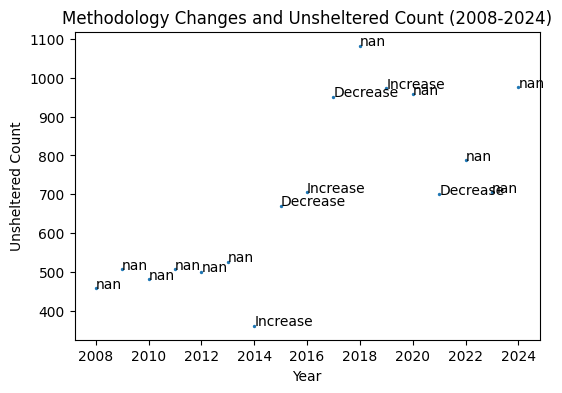

In [87]:
fig, ax = plt.subplots(figsize=(6, 4))
changes=dftt.sort_index()
dftt[['UNimp','Year', 'PhilUN']].info()

ax.scatter(dftt['Year'],dftt['PhilUN'],s=2)

for i, txt in enumerate(dftt['UNimp']):
    ax.annotate(txt, (dftt['Year'][i],dftt['PhilUN'][i]),fontsize=10)

plt.title('Methodology Changes and Unsheltered Count (2008-2024)')
plt.xlabel('Year')
plt.ylabel('Unsheltered Count')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   UNimp2  12 non-null     object 
 1   Year    18 non-null     object 
 2   PhilUN  17 non-null     float64
dtypes: float64(1), object(2)
memory usage: 564.0+ bytes


Text(0, 0.5, 'Unsheltered Count')

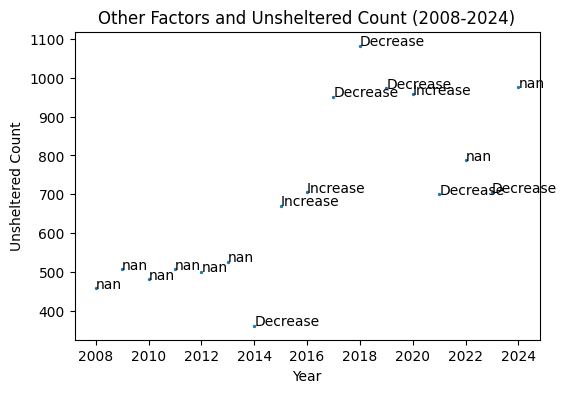

In [88]:
fig, ax = plt.subplots(figsize=(6, 4))
changes=dftt.sort_index()
dftt[['UNimp2','Year', 'PhilUN']].info()

ax.scatter(dftt['Year'],dftt['PhilUN'],s=2)

for i, txt in enumerate(dftt['UNimp2']):
    ax.annotate(txt, (dftt['Year'][i],dftt['PhilUN'][i]),fontsize=10)

plt.title('Other Factors and Unsheltered Count (2008-2024)')
plt.xlabel('Year')
plt.ylabel('Unsheltered Count')

##Uncontrollable variables and the Unsheltered

**Unsheltered Count vs Demolition Number**

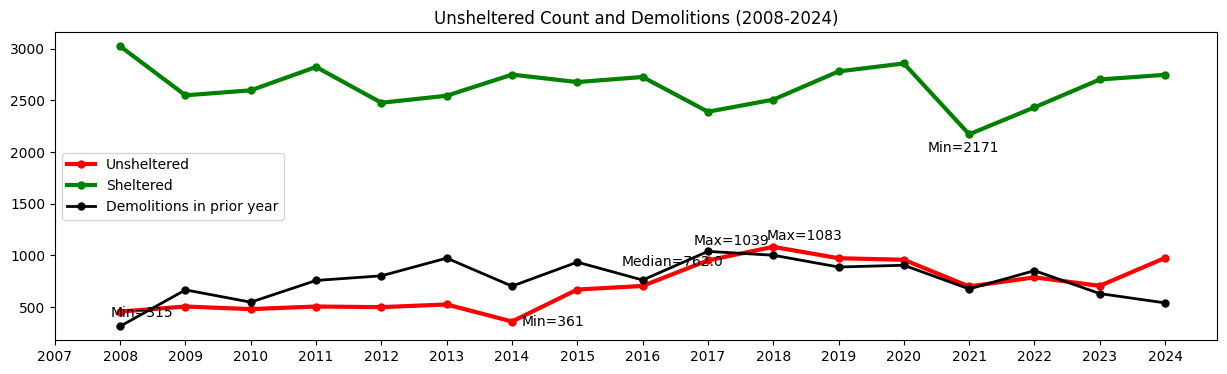

In [53]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'PhilUN', data=pitmerged, marker='o', markerfacecolor='red', markersize=5, color='red', linewidth=3, label="Unsheltered")
ax.plot( 'Year', 'PhilSH', data=pitmerged, marker='o', markerfacecolor='green', markersize=5, color='green', linewidth=3, label="Sheltered")
ax.plot( 'Year', 'demos', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Demolitions in prior year")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
plt.title('Unsheltered Count and Demolitions (2008-2024)')
# plot descriptives UN and SH Counts
medshp=pit.PhilSH.median()
minshp=pit.PhilSH.min()
maxshp=pit.PhilSH.max()
minshp_year = pit.loc[pit['PhilSH'] == minshp, 'Year'].iloc[0]
maxshp_year = pit.loc[pit['PhilSH'] == maxshp, 'Year'].iloc[0]
ax.annotate(f'Min={minshp}', (minshp_year, minshp),fontsize=10, xytext=(-30, -13), textcoords='offset points')
ax.annotate(f'Max={maxshp}', (maxshp_year, maxshp),fontsize=10, xytext=(-25, -20), textcoords='offset points')

medunp=pit.PhilUN.median()
minunp=pit.PhilUN.min()
maxunp=pit.PhilUN.max()
minunp_year = pit.loc[pit['PhilUN'] == minunp, 'Year'].iloc[0]
maxunp_year = pit.loc[pit['PhilUN'] == maxunp, 'Year'].iloc[0]
ax.annotate(f'Min={minunp}', (minunp_year, minunp),fontsize=10, xytext=(7, -3), textcoords='offset points')
ax.annotate(f'Max={maxunp}', (maxunp_year, maxunp),fontsize=10, xytext=(-5, 5), textcoords='offset points')

# plot descriptives demos
#meddem=pitmerged.demos.median()
mindem=pitmerged.demos.min()
maxdem=pitmerged.demos.max()
#meddem_year = pitmerged.loc[pitmerged['demos'] == meddem, 'Year'].iloc[0]
mindem_year = pitmerged.loc[pitmerged['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = pitmerged.loc[pitmerged['demos'] == maxdem, 'Year'].iloc[0]
#ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(-15, 10), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(-7, 7), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(-10, 5), textcoords='offset points')
#plot visual notes
#ax.axvline(2014, color="green", ls="--")
#ax.axvline(2018, color="blue", ls="solid")
ax.legend();

**Interpretation:** There moderate correlation between the number of Unsheltered homeless people and the number of demolitions in the previous calendar year is reflected in this graph. With the increase of demolition projects, the number of Unsheltered homeless people counted the following January increases for most years.

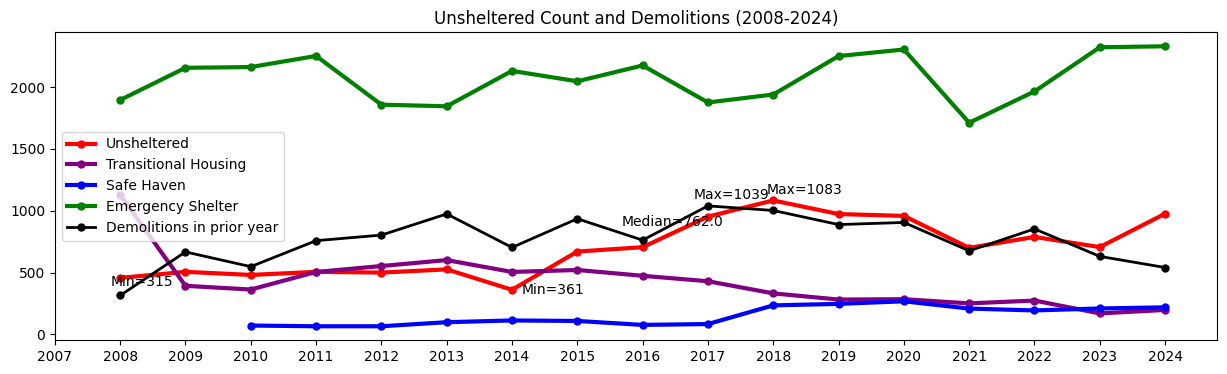

In [54]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'PhilUN', data=pitmerged, marker='o', markerfacecolor='red', markersize=5, color='red', linewidth=3, label="Unsheltered")
ax.plot( 'Year', 'PhilSHTH', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='purple', linewidth=3, label="Transitional Housing")
ax.plot( 'Year', 'PhilSHSH', data=pitmerged, marker='o', markerfacecolor='blue', markersize=5, color='blue', linewidth=3, label="Safe Haven")
ax.plot( 'Year', 'PhilSHES', data=pitmerged, marker='o', markerfacecolor='green', markersize=5, color='green', linewidth=3, label="Emergency Shelter")
ax.plot( 'Year', 'demos', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Demolitions in prior year")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
plt.title('Unsheltered Count and Demolitions (2008-2024)')
# plot descriptives UN and SH Counts

medunp=pit.PhilUN.median()
minunp=pit.PhilUN.min()
maxunp=pit.PhilUN.max()
minunp_year = pit.loc[pit['PhilUN'] == minunp, 'Year'].iloc[0]
maxunp_year = pit.loc[pit['PhilUN'] == maxunp, 'Year'].iloc[0]
ax.annotate(f'Min={minunp}', (minunp_year, minunp),fontsize=10, xytext=(7, -3), textcoords='offset points')
ax.annotate(f'Max={maxunp}', (maxunp_year, maxunp),fontsize=10, xytext=(-5, 5), textcoords='offset points')

# plot descriptives demos
meddem=pitmerged.demos.median()
mindem=pitmerged.demos.min()
maxdem=pitmerged.demos.max()
meddem_year = pitmerged.loc[pitmerged['demos'] == meddem, 'Year'].iloc[0]
mindem_year = pitmerged.loc[pitmerged['demos'] == mindem, 'Year'].iloc[0]
maxdem_year = pitmerged.loc[pitmerged['demos'] == maxdem, 'Year'].iloc[0]
ax.annotate(f'Median={meddem}', (meddem_year, meddem),fontsize=10, xytext=(-15, 10), textcoords='offset points')
ax.annotate(f'Min={mindem}', (mindem_year, mindem),fontsize=10, xytext=(-7, 7), textcoords='offset points')
ax.annotate(f'Max={maxdem}', (maxdem_year, maxdem),fontsize=10, xytext=(-10, 5), textcoords='offset points')
#plot visual notes
#ax.axvline(2014, color="green", ls="--")
#ax.axvline(2018, color="blue", ls="solid")
ax.legend();

Nothing much visually in this one, but it is interesting how most Sheltered people are in Emergency Shelter

**Unsheltered vs Temperature**

In [ ]:
pd.options.mode.copy_on_write = True
pitmerged['shortpit'] = pitmerged['Unsheltered'] / 10

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'shortpit', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="Unsheltered Count")
ax.plot( 'Year', 'Temp', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Temp(F)")
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
plt.title('Unsheltered Count and Avg Min Temp (F) in Jan (2007-2024)')
# plot descriptives Pit
medpit=pitmerged.shortpit.median()
minpit=pitmerged.shortpit.min()
maxpit=pitmerged.shortpit.max()
median_year = pitmerged.loc[pitmerged['shortpit'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['shortpit'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['shortpit'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(-10, 10), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives Temp
medtemp=pitmerged.Temp.median()
mintemp=pitmerged.Temp.min()
maxtemp=pitmerged.Temp.max()
mediantemp_year = pitmerged.loc[pitmerged['Temp'] == medtemp, 'Year'].iloc[0]
mintemp_year = pitmerged.loc[pitmerged['Temp'] == mintemp, 'Year'].iloc[0]
maxtemp_year = pitmerged.loc[pitmerged['Temp'] == maxtemp, 'Year'].iloc[0]
ax.annotate(f'Median={medtemp}', (mediantemp_year, medtemp),fontsize=8, xytext=(0, 0), textcoords='offset points')
ax.annotate(f'Min={mintemp}', (mintemp_year, mintemp),fontsize=8, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxtemp}', (maxtemp_year, maxtemp),fontsize=8, xytext=(0, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2014, color="green", ls="--")
ax.axvline(2017, color="green", ls="--")
ax.axvline(2018, color="blue", ls="solid")
ax.axvline(2021, color="blue", ls="solid")
ax.axvline(2022, color="blue", ls="solid")
ax.axvline(2023, color="blue", ls="solid")
ax.axvline(2024, color="blue", ls="solid")

**Interpretation:** The weak-moderate correlation between the number of Unsheltered homeless people and average minimum temperature in January (r=0.34) is shown in this graph. From years 2008-2013, both the Unsheltered homeless count and the average minimum January temperature remain consistent. There are some years in which we see that an increase or decrease in temperature aligns with a corresponding increase or decrease in the unsheltered count (e.g. 2014, 2017). However, this pattern is switched in later years, which may also require a closer look.

**Unsheltered Count vs Precipitation**

In [ ]:
pd.options.mode.copy_on_write = True
pitmerged['bigprecip'] = pitmerged['Precip'] * 100

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot( 'Year', 'shortpit', data=pitmerged, marker='o', markerfacecolor='purple', markersize=5, color='red', linewidth=3, label="Unsheltered Count")
ax.plot( 'Year', 'bigprecip', data=pitmerged, marker='o', markerfacecolor='black', markersize=5, color='black', linewidth=2, label="Precipitation (in)")
plt.title('Unsheltered Count and Average Precipitation (in) in Jan (2007-2024)')
ax.set_xticks([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
# plot descriptives Pit
medpit=pitmerged.shortpit.median()
minpit=pitmerged.shortpit.min()
maxpit=pitmerged.shortpit.max()
median_year = pitmerged.loc[pitmerged['shortpit'] == medpit, 'Year'].iloc[0]
minpit_year = pitmerged.loc[pitmerged['shortpit'] == minpit, 'Year'].iloc[0]
maxpit_year = pitmerged.loc[pitmerged['shortpit'] == maxpit, 'Year'].iloc[0]
ax.annotate(f'Median={medpit}', (median_year, medpit),fontsize=10, xytext=(10, -10), textcoords='offset points')
ax.annotate(f'Min={minpit}', (minpit_year, minpit),fontsize=10, xytext=(-10, 10), textcoords='offset points')
ax.annotate(f'Max={maxpit}', (maxpit_year, maxpit),fontsize=10, xytext=(5, 0), textcoords='offset points')
# plot descriptives Precipitation
#medpre=pitmerged.bigprecip.median()
minpre=pitmerged.bigprecip.min()
maxpre=pitmerged.bigprecip.max()
#medpre_year = pitmerged.loc[pitmerged['bigprecip'] == medpre, 'Year'].iloc[0]
minpre_year = pitmerged.loc[pitmerged['bigprecip'] == minpre, 'Year'].iloc[0]
maxpre_year = pitmerged.loc[pitmerged['bigprecip'] == maxpre, 'Year'].iloc[0]
#ax.annotate(f'Median={medpre}', (medpre_year, medpre),fontsize=10, xytext=(0, 0), textcoords='offset points')
ax.annotate(f'Min={minpre}', (minpre_year, minpre),fontsize=10, xytext=(10, 0), textcoords='offset points')
ax.annotate(f'Max={maxpre}', (maxpre_year, maxpre),fontsize=10, xytext=(0, 5), textcoords='offset points')
#plot visual notes
ax.axvline(2016, color="green", ls="--")
ax.axvline(2019, color="green", ls="--")
ax.axvline(2023, color="green", ls="--")
ax.axvline(2014, color="blue", ls="solid")
ax.axvline(2018, color="blue", ls="solid")
ax.axvline(2021, color="blue", ls="solid")

**Interpretation:** The weak-moderate correlation between the number of Unsheltered homeless people and average precipitation in January (r=0.32) is shown in this graph. From years 2008-2013, both the Unsheltered homeless count and the average precipitation in January remain consistent. There are some years in which we see that an increase or decrease in temperature aligns with a corresponding decrease or increase in the unsheltered count (e.g. 2016, 2019). However, other years of big changes in the unsheltered population do not align with changes in precipitation (e.g. 2014, 2018, 2021).

##Philadelphia vs Camden

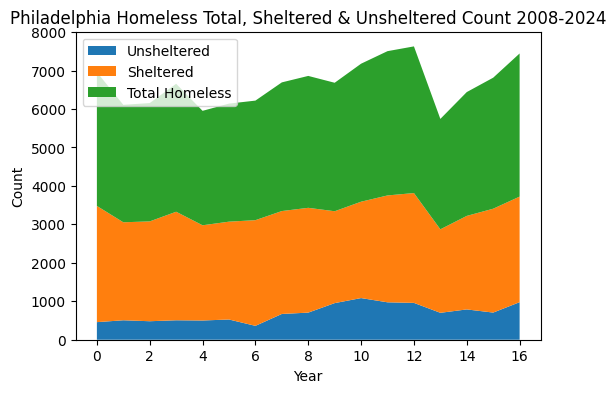

In [89]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(range(17),pitmerged["PhilUN"], pitmerged["PhilSH"], pitmerged["PhilPIT"],labels=['Unsheltered', 'Sheltered', 'Total Homeless'])
#ax.set_xticks([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
ax.legend(loc='upper left')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Philadelphia Homeless Total, Sheltered & Unsheltered Count 2008-2024');
#ax.margins(2008, 2024)
#ax.title('100 % stacked area chart')


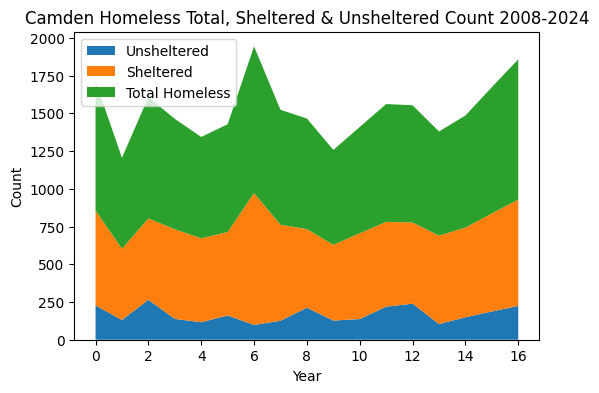

In [42]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(range(17),pitmerged["CamUN"], pitmerged["CamSH"], pitmerged["CamPIT"],labels=['Unsheltered', 'Sheltered', 'Total Homeless'])
#ax.set_xticks([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
ax.legend(loc='upper left')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Camden Homeless Total, Sheltered & Unsheltered Count 2008-2024');
#ax.margins(2008, 2024)
#ax.title('100 % stacked area chart');

**Interpretation of Visuals:** <br>
*PIT Counts:* The number of unsheltered people makes up a fraction of the total of counted homeless individuals. The pattern of sheltered homeless people is nearly identical to overall count, highlighting how influential this number is to the overall count report compared to unsheltered.


In [ ]:
pit[['PhilPIT','CamPIT','Year']].groupby('Year').describe().round(2)

PhilPIT                                                     CamPIT  \
       count    mean std     min     25%     50%     75%     max  count   
Year                                                                      
2007     1.0  3869.0 NaN  3869.0  3869.0  3869.0  3869.0  3869.0    1.0   
2008     1.0  3479.0 NaN  3479.0  3479.0  3479.0  3479.0  3479.0    1.0   
2009     1.0  3054.0 NaN  3054.0  3054.0  3054.0  3054.0  3054.0    1.0   
2010     1.0  3077.0 NaN  3077.0  3077.0  3077.0  3077.0  3077.0    1.0   
2011     1.0  3328.0 NaN  3328.0  3328.0  3328.0  3328.0  3328.0    1.0   
2012     1.0  2976.0 NaN  2976.0  2976.0  2976.0  2976.0  2976.0    1.0   
2013     1.0  3070.0 NaN  3070.0  3070.0  3070.0  3070.0  3070.0    1.0   
2014     1.0  3109.0 NaN  3109.0  3109.0  3109.0  3109.0  3109.0    1.0   
2015     1.0  3346.0 NaN  3346.0  3346.0  3346.0  3346.0  3346.0    1.0   
2016     1.0  3430.0 NaN  3430.0  3430.0  3430.0  3430.0  3430.0    1.0   
2017     1.0  3341.0 NaN  3341.0  3341.0  3341.0  3341.0  3341.0    1.0   
2018     1.0  3589.0 NaN  3589.0  3589.0  3589.0  3589.0  3589.0    1.0   
2019     1.0  3752.0 NaN  3752.0  3752.0  3752.0  3752.0  3752.0    1.0   
2020     1.0  3814.0 NaN  3814.0  3814.0  3814.0  3814.0  3814.0    1.0   
2021     1.0  2871.0 NaN  2871.0  2871.0  2871.0  2871.0  2871.0    1.0   
2022     1.0  3220.0 NaN  3220.0  3220.0  3220.0  3220.0  3220.0    1.0   
2023     1.0  3407.0 NaN  3407.0  3407.0  3407.0  3407.0  3407.0    1.0   
2024     1.0  3722.0 NaN  3722.0  3722.0  3722.0  3722.0  3722.0    1.0   

                                                          
        mean std     min     25%     50%     75%     max  
Year                                                      
2007  1005.0 NaN  1005.0  1005.0  1005.0  1005.0  1005.0  
2008   856.0 NaN   856.0   856.0   856.0   856.0   856.0  
2009   603.0 NaN   603.0   603.0   603.0   603.0   603.0  
2010   804.0 NaN   804.0   804.0   804.0   804.0   804.0  
2011   732.0 NaN   732.0   732.0   732.0   732.0   732.0  
2012   672.0 NaN   672.0   672.0   672.0   672.0   672.0  
2013   714.0 NaN   714.0   714.0   714.0   714.0   714.0  
2014   972.0 NaN   972.0   972.0   972.0   972.0   972.0  
2015   762.0 NaN   762.0   762.0   762.0   762.0   762.0  
2016   733.0 NaN   733.0   733.0   733.0   733.0   733.0  
2017   629.0 NaN   629.0   629.0   629.0   629.0   629.0  
2018   705.0 NaN   705.0   705.0   705.0   705.0   705.0  
2019   781.0 NaN   781.0   781.0   781.0   781.0   781.0  
2020   777.0 NaN   777.0   777.0   777.0   777.0   777.0  
2021   690.0 NaN   690.0   690.0   690.0   690.0   690.0  
2022   743.0 NaN   743.0   743.0   743.0   743.0   743.0  
2023   837.0 NaN   837.0   837.0   837.0   837.0   837.0  
2024   929.0 NaN   929.0   929.0   929.0   929.0   929.0